# Лабораторна робота №1
## Linear Regression

### Мета роботи:
навчитись реалізовувати лінійну регресію та градієнтний спуск.

1. Підключення бібліотек і завантаження даних

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
train_data = np.genfromtxt('lab_1_train.csv', delimiter=',', skip_header=1)
test_data = np.genfromtxt('lab_1_test.csv', delimiter=',', skip_header=1)

In [3]:
print(train_data[:5])
print(test_data[:5])

[[0.00000000e+00 0.00000000e+00 2.01490142e+01]
 [1.00000000e+00 1.01010101e-02 1.99787227e+01]
 [2.00000000e+00 2.02020202e-02 2.02347106e+01]
 [3.00000000e+00 3.03030303e-02 2.05175150e+01]
 [4.00000000e+00 4.04040404e-02 2.00105621e+01]]
[[ 0.          0.60606061 21.06836894]
 [ 1.          0.61616162 21.17662554]
 [ 2.          0.62626263 20.92062476]
 [ 3.          0.63636364 20.91386529]
 [ 4.          0.64646465 21.53668704]]


2. Підготовка даних

In [4]:
# Дані для навчання
x_train = train_data[:, 1]
y_train = train_data[:, 2]

# Дані для тестування
x_test = test_data[:, 1]
y_test = test_data[:, 2]

In [5]:
print("x_train:", x_train[:5])
print("y_train:", y_train[:5])
print("x_test:", x_test[:5])
print("y_test:", y_test[:5])

x_train: [0.         0.01010101 0.02020202 0.03030303 0.04040404]
y_train: [20.14901425 19.97872273 20.2347106  20.51751502 20.01056207]
x_test: [0.60606061 0.61616162 0.62626263 0.63636364 0.64646465]
y_test: [21.06836894 21.17662554 20.92062476 20.91386529 21.53668704]


3. Візуалізація тренувальних даних

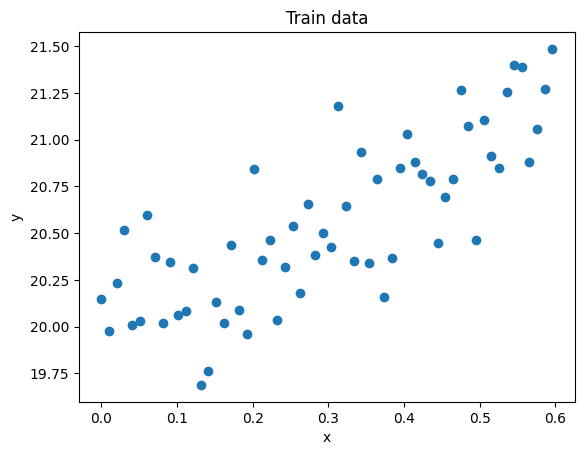

In [6]:
plt.scatter(x_train, y_train)

plt.xlabel('x')
plt.ylabel('y')
plt.title('Train data')

plt.show()

4. Реалізація моделі лінійної регресії

In [7]:
w = 0.0
b = 0.0

In [8]:
def predict(x, w, b):
    return w * x + b

In [9]:
y_pred = predict(x_train, w, b)

5. Реалізація функції витрат

In [10]:
def mse(y_true, y_pred):
    m = len(y_true)
    return (1 / (2 * m)) * np.sum((y_pred - y_true) ** 2)

In [11]:
loss = mse(y_train, y_pred)
print("MSE:", loss)

MSE: 211.23870094240354


6. Обчислення градієнтів

In [12]:
def compute_gradients(x, y_true, y_pred):
    m = len(y_true)

    dw = (1 / m) * np.sum((y_pred - y_true) * x)
    db = (1 / m) * np.sum(y_pred - y_true)

    return dw, db

7. Навчання моделі методом градієнтного спуску

In [13]:
learning_rate = 0.01
epochs = 10000
epsilon = 1e-4

In [14]:
previous_loss = float('inf')

for epoch in range(epochs):
    # прогноз
    y_pred = predict(x_train, w, b)
    loss = mse(y_train, y_pred)

    # перевірка збіжності
    if abs(previous_loss - loss) < epsilon:
        print(f"Gradient descent converged at epoch {epoch + 1}")
        break
        
    # градієнти
    dw, db = compute_gradients(x_train, y_train, y_pred)

    # оновлені параметри
    w = w - learning_rate * dw
    b = b - learning_rate * db

    print(f"Epoch {epoch + 1}: w = {w}, b = {b}, loss = {loss}")

Epoch 1: w = 0.06183906732682434, b = 0.20549563191038453, loss = 211.23870094240354
Epoch 2: w = 0.12299196792752087, b = 0.40875203957377215, loss = 206.65857757979356
Epoch 3: w = 0.18346619347012755, b = 0.6097936598708571, loss = 202.17787676259215
Epoch 4: w = 0.243269153861219, b = 0.8086446629898695, loss = 197.79444023128175
Epoch 5: w = 0.3024081781382132, b = 1.0053289553371325, loss = 193.50615657776237
Epoch 6: w = 0.3608905153519401, b = 1.199870182415855, loss = 189.31096022830326
Epoch 7: w = 0.4187233354395782, b = 1.392291731673507, loss = 185.20683044857154
Epoch 8: w = 0.47591373008806426, b = 1.5826167353181193, loss = 181.19179037026075
Epoch 9: w = 0.5324687135880805, b = 1.770868073103848, loss = 177.26390603884835
Epoch 10: w = 0.5883952236787213, b = 1.9570683750861386, loss = 173.4212854820251
Epoch 11: w = 0.643700122382942, b = 2.1412400243468213, loss = 169.6620777983464
Epoch 12: w = 0.6983901968338898, b = 2.323405159689465, loss = 165.98447226566788
Epo

8. Перевірка моделі на тестових даних

In [15]:
y_test_pred = predict(x_test, w, b)

In [16]:
test_loss = mse(y_test, y_test_pred)

print("Test loss:", test_loss)

Test loss: 0.03940932157027175


9. Візуалізація результатів

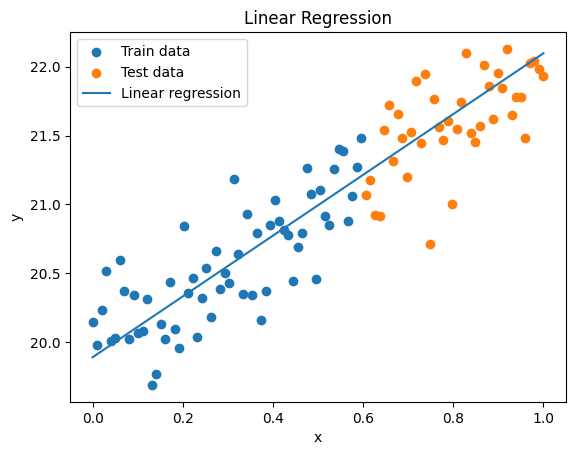

In [17]:
plt.scatter(x_train, y_train, label='Train data')
plt.scatter(x_test, y_test, label='Test data')

# Лінія лінійної регресії
x_line = np.linspace(
    min(np.min(x_train), np.min(x_test)),
    max(np.max(x_train), np.max(x_test)),
    100
)

y_line = predict(x_line, w, b)

plt.plot(x_line, y_line, label='Linear regression')

plt.xlabel('x')
plt.ylabel('y')
plt.title('Linear Regression')
plt.legend()

plt.show()

### Висновок
У ході лабораторної роботи було реалізовано модель лінійної регресії та її навчання методом градієнтного спуску. Проведено навчання на тренувальних даних, перевірено модель на тестових даних та візуалізовано отримані результати.